<img width=600 height=300 src="https://imgs.xkcd.com/comics/sustainable.png"/>
***

# Lab: Logistic Regression

## Learning Objectives
By the end of this lab, you will be able to:
- Understand the difference between linear and logistic regression
- Implement binary logistic regression for classification tasks
- Visualize decision boundaries and model performance
- Evaluate classification models using appropriate metrics
- Use validation sets for feature selection and regularization tuning
- Extend logistic regression to multi-class problems

## Introduction

While linear regression predicts continuous values, **logistic regression** is used for **classification** - predicting discrete categories. Despite its name, logistic regression is a classification algorithm!

The key difference is that logistic regression uses the **sigmoid function** (also called the logistic function) to map predictions to probabilities between 0 and 1:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

where $z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n$

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import preprocessing

# Set random seed for reproducibility
np.random.seed(42)

# Set plot style
plt.rcParams['figure.figsize'] = (10, 6)

## Part 1: Understanding the Sigmoid Function

Let's start by visualizing the sigmoid function to understand how it transforms linear predictions into probabilities.

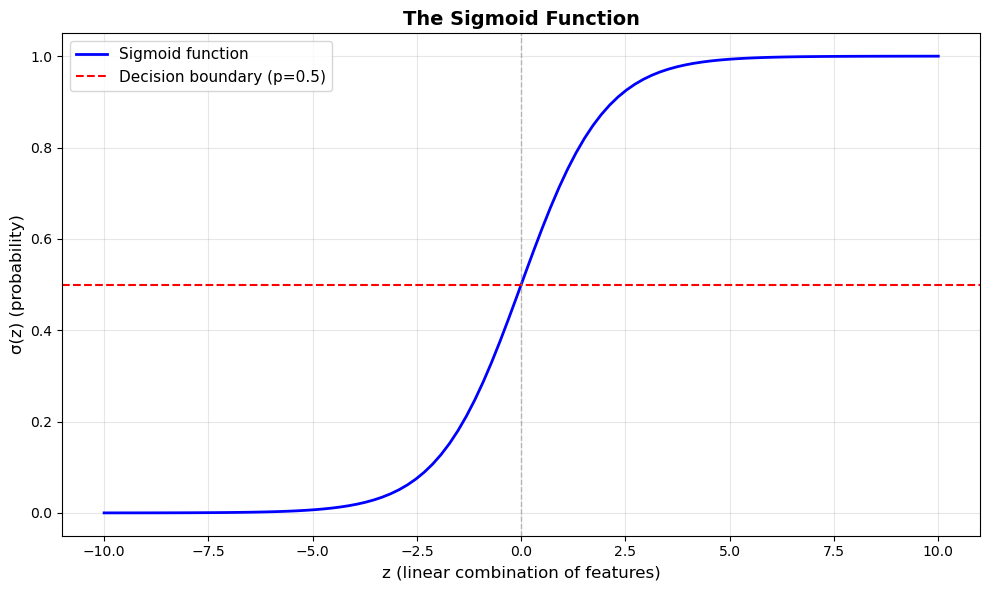

Key observations:
- When z = 0, σ(z) = 0.500
- When z → -∞, σ(z) → 0
- When z → +∞, σ(z) → 1
- The function is always between 0 and 1, making it perfect for probabilities!


In [2]:
def sigmoid(z):
    """Compute the sigmoid function"""
    return 1 / (1 + np.exp(-z))

# Create a range of values
z = np.linspace(-10, 10, 100)
y = sigmoid(z)

# Plot the sigmoid function
plt.figure(figsize=(10, 6))
plt.plot(z, y, 'b-', linewidth=2, label='Sigmoid function')
plt.axhline(y=0.5, color='r', linestyle='--', linewidth=1.5, label='Decision boundary (p=0.5)')
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
plt.xlabel('z (linear combination of features)', fontsize=12)
plt.ylabel('σ(z) (probability)', fontsize=12)
plt.title('The Sigmoid Function', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("Key observations:")
print(f"- When z = 0, σ(z) = {sigmoid(0):.3f}")
print(f"- When z → -∞, σ(z) → 0")
print(f"- When z → +∞, σ(z) → 1")
print(f"- The function is always between 0 and 1, making it perfect for probabilities!")

## Part 2: Binary Classification Example, Space Shuttle

From http://www.edwardtufte.com/tufte/ebooks, in "Visual and Statistical Thinking: 
Displays of Evidence for Making Decisions":

>On January 28, 1986, the space shuttle Challenger exploded and seven astronauts died because two rubber O-rings leaked. These rings had lost their resiliency because the shuttle was launched on a very cold day. Ambient temperatures were in the low 30s and the O-rings themselves were much colder, less than 20F.

>One day before the flight, the predicted temperature for the launch was 26F to 29F. Concerned that the rings would not seal at such a cold temperature, the engineers who designed the rocket opposed launching Challenger the next day.

But they did not make their case persuasively, and were over-ruled by NASA.

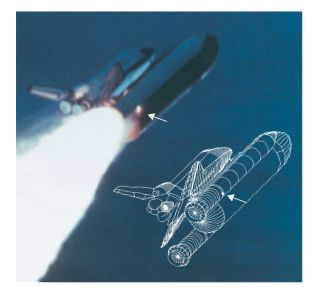

In [3]:
from IPython.display import Image as Im
from IPython.display import display
Im('shuttle.png')

The image above shows the leak, where the O-ring failed.

We have here data on previous failures of the O-rings at various temperatures (loading the file chall.txt)

In [4]:
data=np.array([[float(j) for j in e.strip().split()] for e in open("chall.txt")])
data

array([[66.,  0.],
       [70.,  1.],
       [69.,  0.],
       [68.,  0.],
       [67.,  0.],
       [72.,  0.],
       [73.,  0.],
       [70.,  0.],
       [57.,  1.],
       [63.,  1.],
       [70.,  1.],
       [78.,  0.],
       [67.,  0.],
       [53.,  1.],
       [67.,  0.],
       [75.,  0.],
       [70.,  0.],
       [81.,  0.],
       [76.,  0.],
       [79.,  0.],
       [75.,  1.],
       [76.,  0.],
       [58.,  1.]])

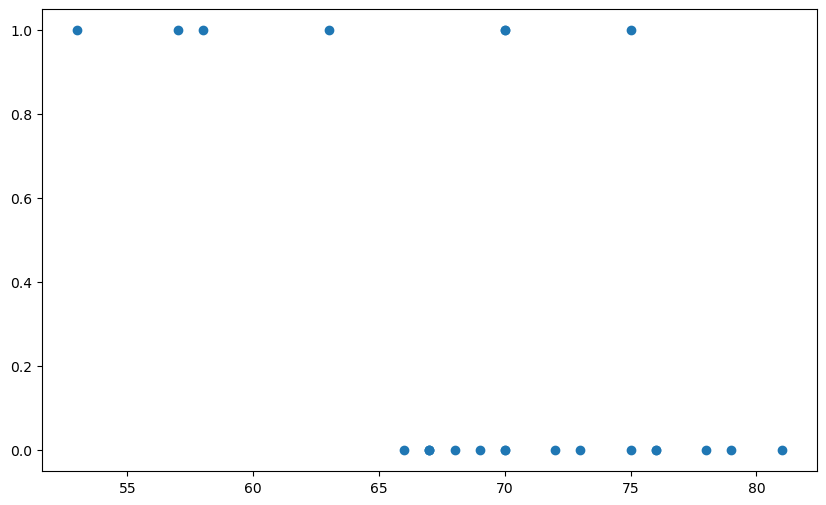

In [5]:
dat = pd.DataFrame(data, columns = ['Temp', 'Failure'])
plt.scatter(dat["Temp"],dat["Failure"])

### Let's see if we can come up with a model for this

In [6]:
from sklearn.linear_model import LogisticRegression

In [7]:
model = LogisticRegression()

In [8]:
X = dat["Temp"].values
y = dat["Failure"].values
y

array([0., 1., 0., 0., 0., 0., 0., 0., 1., 1., 1., 0., 0., 1., 0., 0., 0.,
       0., 0., 0., 1., 0., 1.])

In [9]:
model.fit(X.reshape(-1,1),y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

model.score will give us the accuracy, this will be on the training data, no validation

In [10]:
model.score(X.reshape(-1,1),y)

0.8695652173913043

### Now let's plot the graph of predictions

linspace gives us all the x's we need, we make the y predictions based on this and the plot should show the picture

(-0.1, 1.1)

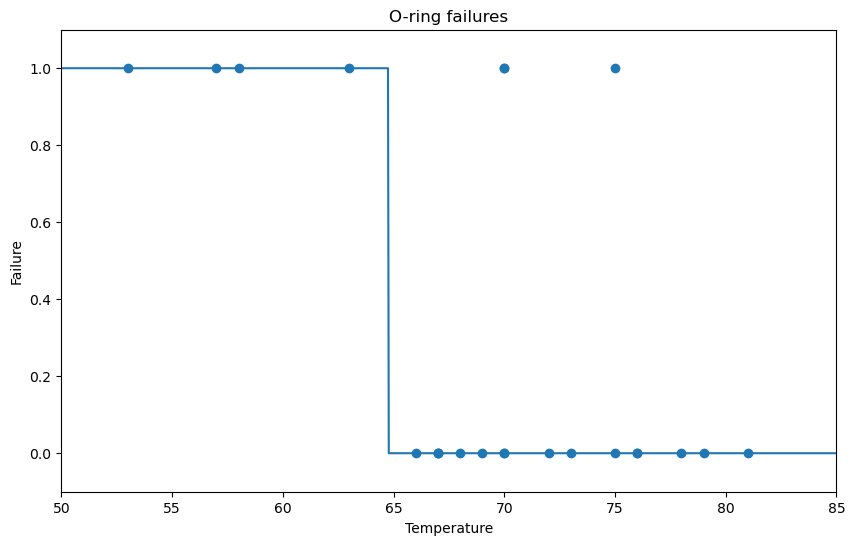

In [11]:
x = np.linspace(50, 85, 1000)
y_pred = model.predict(x.reshape(-1,1))
temps, pfail = data[:,0], data[:,1]
plt.scatter(temps, pfail)
axes=plt.gca()
plt.xlabel('Temperature')
plt.ylabel('Failure')
plt.title('O-ring failures')

# plot fitted values
plt.plot(x, y_pred)

# change limits, for a nicer plot
plt.xlim(50, 85)
plt.ylim(-0.1, 1.1)

#Something very wrong in this picture!

That's not what logistic regression should look!

model.predict only predicts 1 or 0, it does not give in between "probabilities" like we need

(-0.1, 1.1)

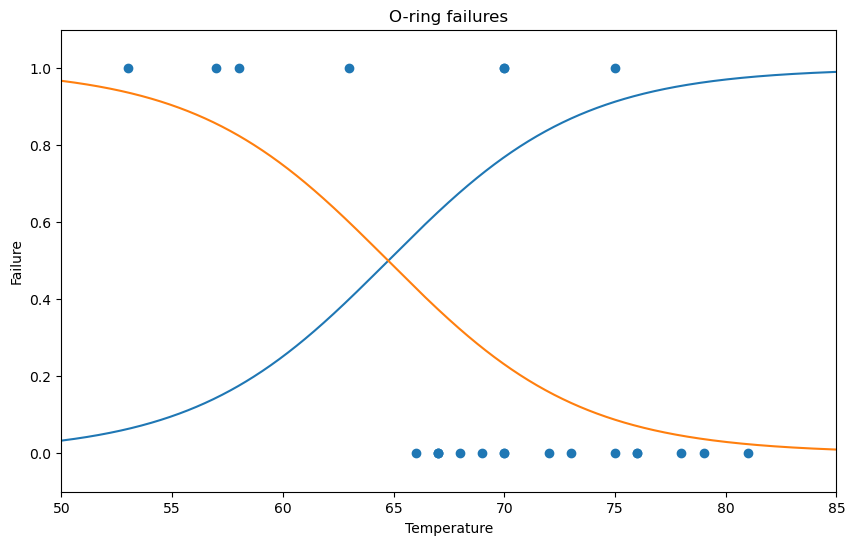

In [12]:
x = np.linspace(50, 85, 1000)
y_predprob = model.predict_proba(x.reshape(-1,1))
temps, pfail = data[:,0], data[:,1]
plt.scatter(temps, pfail)
axes=plt.gca()
plt.xlabel('Temperature')
plt.ylabel('Failure')
plt.title('O-ring failures')

# plot fitted values
plt.plot(x, y_predprob)

# change limits, for a nicer plot
plt.xlim(50, 85)
plt.ylim(-0.1, 1.1)

#Something very wrong in this picture!

It gives two plots. That is because if you look at y_predprob you have two things

In [13]:
y_predprob[0]

array([0.03270804, 0.96729196])

The first one is the probability for 0 while the second one is the probability for 1. Now only plot one

(-0.1, 1.1)

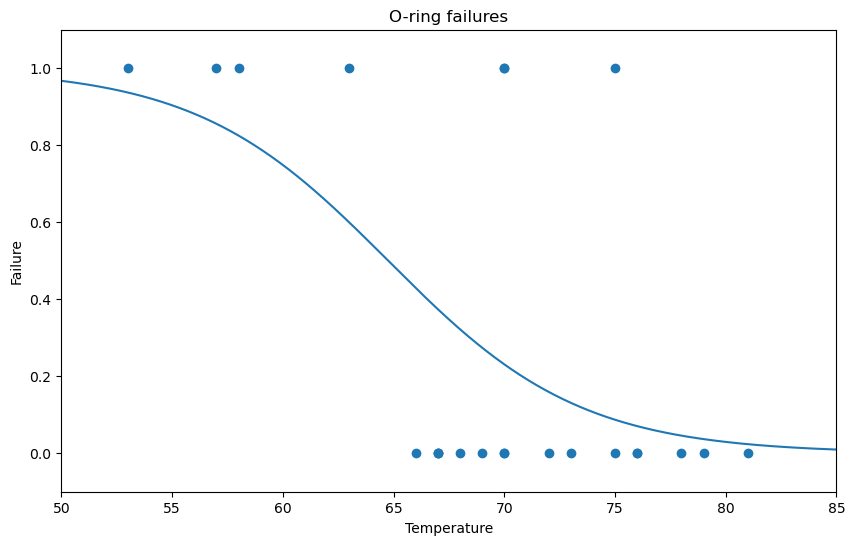

In [14]:
temps, pfail = data[:,0], data[:,1]
plt.scatter(temps, pfail)
axes=plt.gca()
plt.xlabel('Temperature')
plt.ylabel('Failure')
plt.title('O-ring failures')

# plot fitted values
plt.plot(x, y_predprob[:,1])

# change limits, for a nicer plot
plt.xlim(50, 85)
plt.ylim(-0.1, 1.1)

## Part 3: Binary Classification - Heart Disease Prediction

### 3.1 Load and Explore the Data

We'll work with a heart disease dataset that contains information about patients and whether they have heart disease.

In [15]:
# Load the dataset
df = pd.read_csv('heart_disease.csv')

# Display basic information
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset info:")
print(df.info())
print("\nBasic statistics:")
print(df.describe())
print("\nClass distribution:")
print(df['heart_disease'].value_counts())

Dataset shape: (500, 7)

First few rows:
   age  cholesterol  blood_pressure  max_heart_rate  exercise_hours   bmi  \
0   68          325             159             115             7.4  28.5   
1   58          234             159             170             8.7  37.7   
2   44          188              93             116             4.3  25.1   
3   72          249             164             122             0.4  20.8   
4   37          182             151             125             1.6  28.4   

   heart_disease  
0              1  
1              0  
2              0  
3              0  
4              0  

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             500 non-null    int64  
 1   cholesterol     500 non-null    int64  
 2   blood_pressure  500 non-null    int64  
 3   max_heart_rate  500 non-null    i

**YOUR CODE HERE**: Create a visualization to explore the relationship between features and the target variable. 

Hint: Create a 2x3 subplot showing how each feature relates to heart disease. You could use histograms, box plots, or scatter plots.

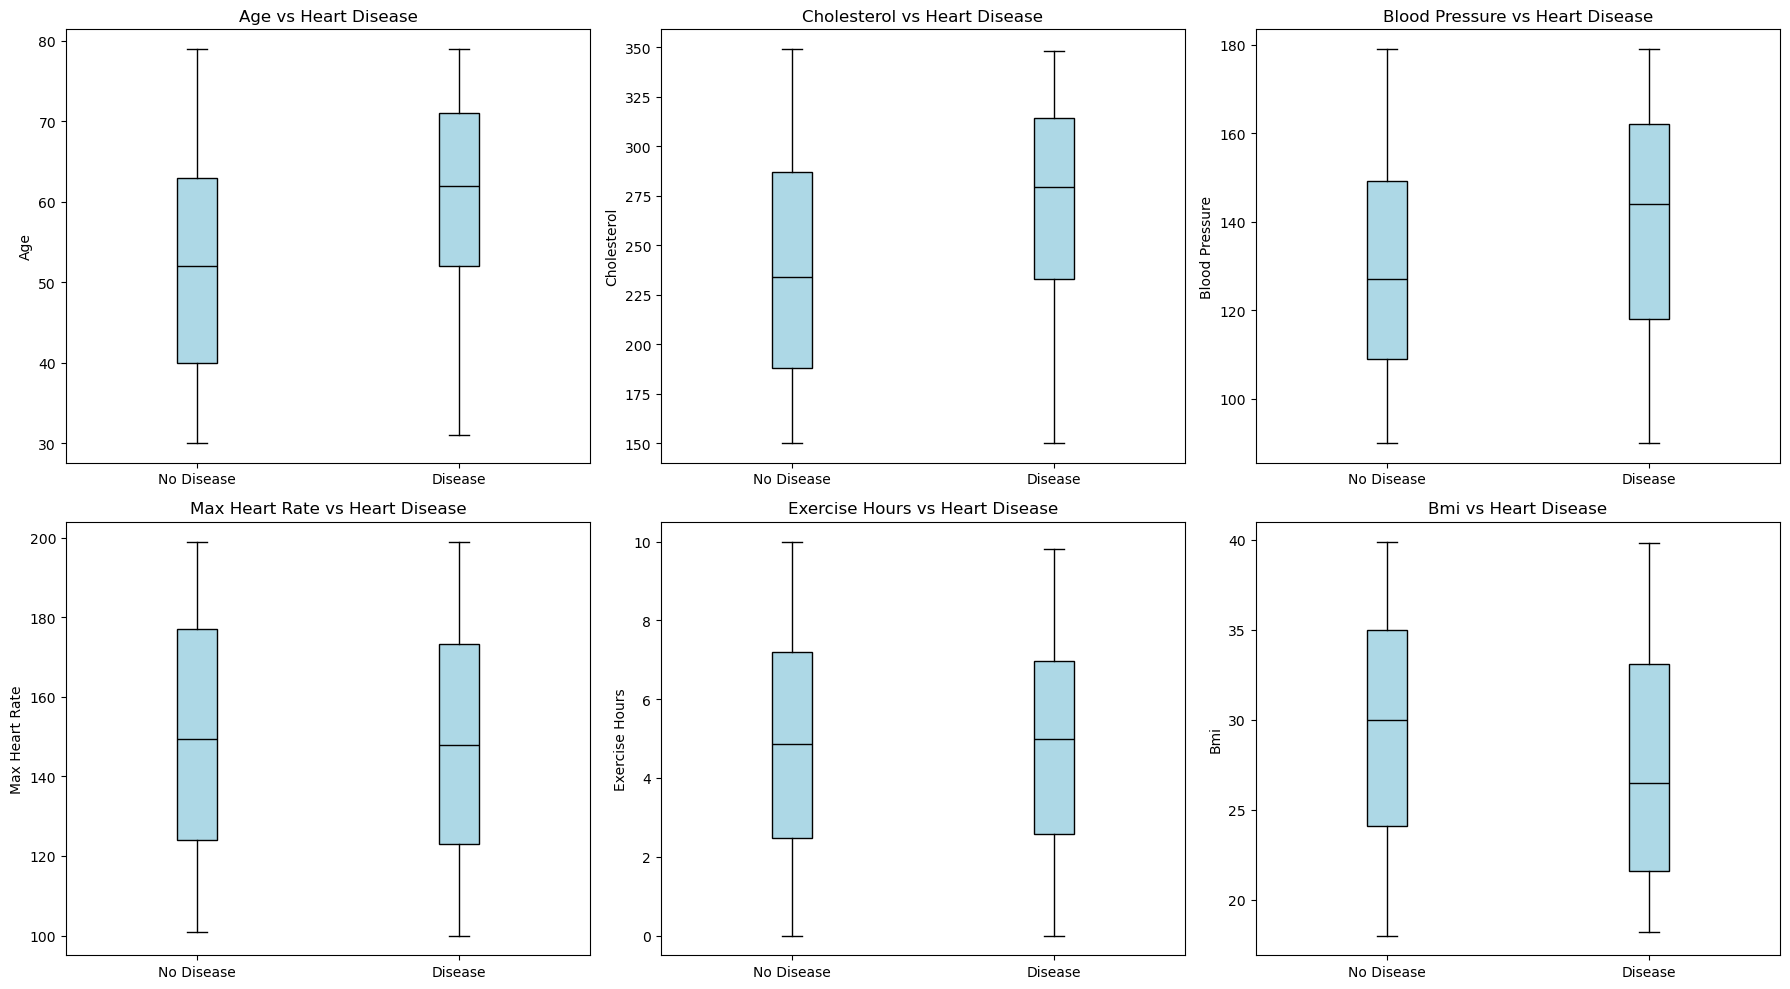

In [16]:
# YOUR CODE HERE
# Create visualizations to explore feature relationships with heart disease
# Example: Create subplots for each feature
features = df.columns.drop("heart_disease")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, feature in enumerate(features):
    no_disease = df[df["heart_disease"] == 0][feature]
    disease = df[df["heart_disease"] == 1][feature]

    axes[i].boxplot(
        [no_disease, disease],
        tick_labels=["No Disease", "Disease"],
        patch_artist=True,
        boxprops=dict(facecolor="lightblue"),
        medianprops=dict(color="black")
    )

    axes[i].set_title(f"{feature.replace('_', ' ').title()} vs Heart Disease")
    axes[i].set_ylabel(feature.replace('_', ' ').title())

plt.tight_layout()
plt.show()

### 3.2 Prepare the Data

**YOUR CODE HERE**: 
1. Separate features (X) and target (y)
2. Split the data into train (80%), validation (20%)
3. Remember to set random_state=42 for reproducibility

In [17]:
# YOUR CODE HERE
# Separate features and target
X = df.drop("heart_disease", axis=1).values
y = df["heart_disease"].values

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

### 3.3 Feature Scaling

Logistic regression performs better when features are on similar scales. Let's standardize our features.

StandardScaler makes all features have mean 0 and standard deviation 1

We need to ensure this is done on all sets

In [18]:
# Initialize the scaler
scaler = preprocessing.StandardScaler()

# Fit on training data and transform all sets
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("Feature scaling complete!")
print(f"Training set shape: {X_train_scaled.shape}")
print(f"Validation set shape: {X_val_scaled.shape}")

Feature scaling complete!
Training set shape: (400, 6)
Validation set shape: (100, 6)


### 3.4 Train a Basic Logistic Regression Model

**YOUR CODE HERE**: Create and train a logistic regression model using all features.

In [19]:
# YOUR CODE HERE
# Create a LogisticRegression model and fit it to the training data
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

### 3.5 Evaluate the Model

**YOUR CODE HERE**: 
1. Make predictions on the validation set
2. Calculate and print the accuracy

In [20]:
# YOUR CODE HERE
# Make predictions on validation set
y_val_pred = model.predict(X_val_scaled)

# Calculate accuracy
accuracy = model.score(X_val_scaled, y_val)

print(f"Validation Accuracy: {accuracy:.3f}")

Validation Accuracy: 0.740


### 3.6 Visualize Model Coefficients

Let's examine which features are most important according to our model.

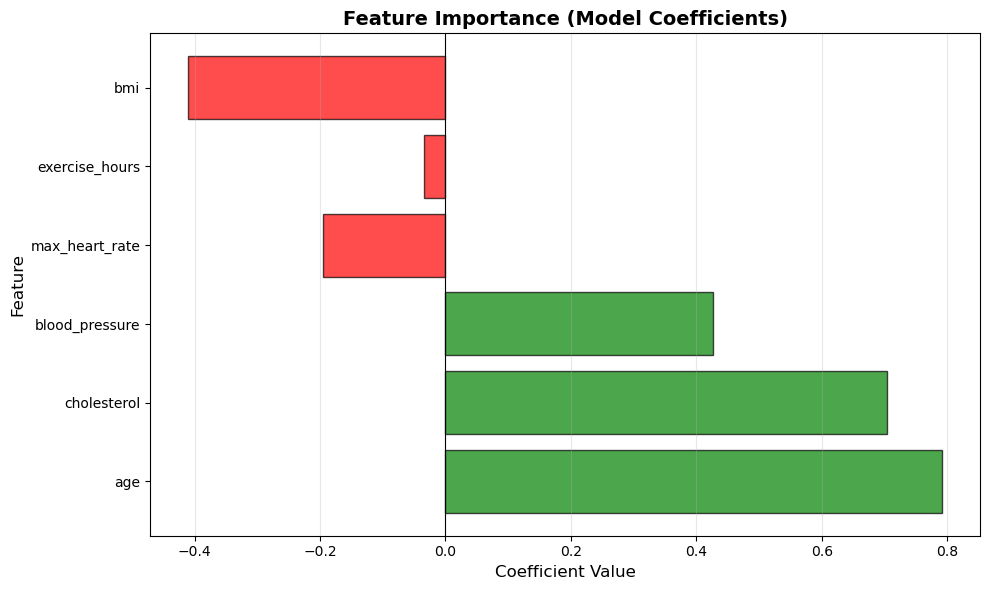


Coefficient interpretation:
- Positive coefficients increase the probability of heart disease
- Negative coefficients decrease the probability of heart disease
- Larger absolute values indicate stronger influence


In [21]:
# Get feature names and coefficients
feature_names = df.drop("heart_disease", axis=1).columns
coefficients = model.coef_[0]

# Create a bar plot
plt.figure(figsize=(10, 6))
colors = ['red' if c < 0 else 'green' for c in coefficients]
plt.barh(feature_names, coefficients, color=colors, alpha=0.7, edgecolor='black')
plt.xlabel('Coefficient Value', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Feature Importance (Model Coefficients)', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\nCoefficient interpretation:")
print("- Positive coefficients increase the probability of heart disease")
print("- Negative coefficients decrease the probability of heart disease")
print("- Larger absolute values indicate stronger influence")

## Part 4: Feature Selection Using Validation Set

Not all features may be useful. Let's use the validation set to determine which features to include.

### 4.1 Forward Selection

**YOUR CODE HERE**: Implement forward feature selection:
1. Start with no features
2. Try adding each remaining feature one at a time
3. Keep the feature that gives the best validation accuracy
4. Repeat until adding features no longer improves validation accuracy

Track the validation accuracy as you add features and store the selected features.

In [24]:
# YOUR CODE HERE
# Implement forward feature selection

# Initialize
selected_features = []
accuracy_history = []
best_accuracy = 0

for i in range(6):
    selected_features.append(i)
    model = LogisticRegression()
    print(selected_features)
    model.fit(X_train_scaled[:, selected_features], y_train)
    accuracy = model.score(X_val_scaled[:, selected_features], y_val)
    if(accuracy > best_accuracy):
        best_accuracy = accuracy
    accuracy_history.append(accuracy)

[0]
[0, 1]
[0, 1, 2]
[0, 1, 2, 3]
[0, 1, 2, 3, 4]
[0, 1, 2, 3, 4, 5]


**YOUR CODE HERE**: Create a plot showing how validation accuracy changes as you add features.

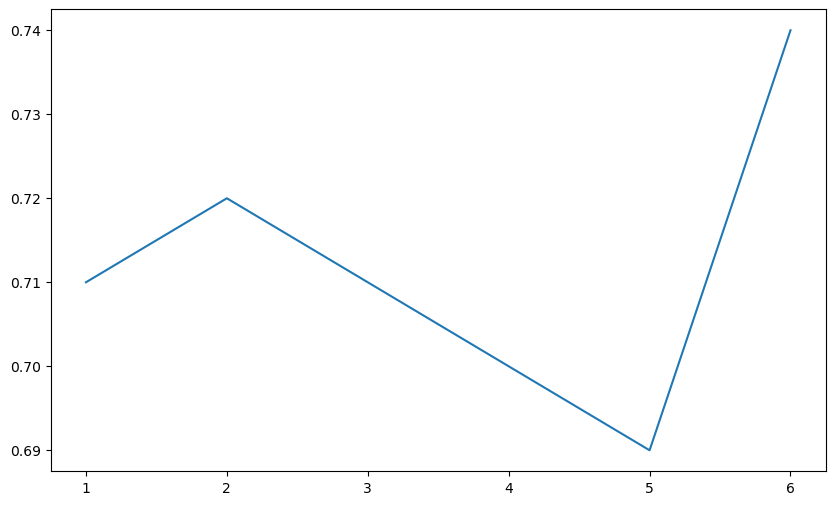

In [32]:
# YOUR CODE HERE
# Plot validation accuracy vs number of features
plt.plot(range(1,7), accuracy_history)
plt.show()

### 4.2 Train Final Model with Selected Features

**YOUR CODE HERE**: Train a model using only the selected features, combine both X_train and X_val in final model

In [40]:
# YOUR CODE HERE
# Train model with selected features
# Evaluate on test set
X_final = np.concatenate([X_train_scaled, X_val_scaled], axis=0)
y_final = np.concatenate([y_train, y_val], axis=0)

X_selected = X_final[:, selected_features]

model = LogisticRegression(max_iter=100, random_state=42)
model.fit(X_selected, y_final)

y_pred = model.predict(X_selected)
accuracy = accuracy_score(y_final, y_pred)

# Calculate accuracy
accuracy = model.score(X_val_scaled, y_val)

print(f"Test set accuracy: {accuracy:.3f}")


NameError: name 'accuracy_score' is not defined

## Part 5: Regularisation

Regularisation helps prevent overfitting by penalizing large coefficients. Logistic regression in scikit-learn uses the `C` parameter, where smaller values mean stronger regularisation.

Your lecturer will talk about this in a lecture

### 5.1 Understanding the C Parameter

The parameter `C` is the inverse of regularization strength:
- **Large C** (e.g., 100): Weak regularization → Model can fit training data closely (risk of overfitting)
- **Small C** (e.g., 0.01): Strong regularization → Simpler model (risk of underfitting)

### 5.2 Selecting the Best C Value

**YOUR CODE HERE**: 
1. Try different values of C: [0.001, 0.01, 0.1, 1, 10, 100]
2. For each C value, train a model and evaluate on the validation set
3. Track both training and validation accuracy
4. Select the C value that gives the best validation accuracy

In [ ]:
LogisticRegression?

In [ ]:
# YOUR CODE HERE
# Test different C values
# C_values = [0.001, 0.01, 0.1, 1, 10, 100]
# train_accuracies = []
# val_accuracies = []

# for C in C_values:
#     # Train model with this C value
#     # Calculate train and validation accuracy
#     # Store results



**YOUR CODE HERE**: Create a plot showing training and validation accuracy for different C values. This plot should help you identify overfitting or underfitting.

In [ ]:
# YOUR CODE HERE
# Plot training and validation accuracy vs C
# Use a log scale for the x-axis (plt.xscale('log'))



**YOUR CODE HERE**: Train a final model with the best C value and evaluate it on the test set.

In [ ]:
# YOUR CODE HERE
# Train final model with best C
# Evaluate on test set



### 5.3 Visualizing the Effect of Regularisation

**YOUR CODE HERE**: Create a plot showing how the magnitude of coefficients changes with different C values. This visualizes how regularisation affects the model.

In [ ]:
# YOUR CODE HERE
# For each C value, get the coefficients and plot them
# Create a plot with C on x-axis (log scale) and coefficient values on y-axis
# Use different colors/lines for each feature



## Part 6: Multi-class Classification - Wine Quality Prediction

Now let's extend to a multi-class problem. Logistic regression can handle this using a "one-vs-rest" approach.

### 6.1 Load and Explore the Data

In [ ]:
# Load the wine quality dataset
wine_df = pd.read_csv('wine_quality.csv')

print("Dataset shape:", wine_df.shape)
print("\nFirst few rows:")
print(wine_df.head())
print("\nClass distribution:")
print(wine_df['quality'].value_counts().sort_index())

**YOUR CODE HERE**: Create visualizations to explore the wine dataset. Consider creating:
- Distribution of features for each quality class
- Correlation between features
- Any other exploratory plots you think would be useful

In [ ]:
# YOUR CODE HERE
# Explore the wine dataset visually



### 6.2 Prepare the Data

**YOUR CODE HERE**: 
1. Separate features and target
2. Split into train/validation/test sets (60/20/20) (train_test_split can be used twice)
3. Scale the features

In [ ]:
# YOUR CODE HERE
# Prepare the wine dataset



### 6.3 Train Multi-class Logistic Regression

**YOUR CODE HERE**: Train a multi-class logistic regression model. Note that scikit-learn handles multi-class automatically!

In [ ]:
# YOUR CODE HERE
# Train multi-class logistic regression
# Use multi_class='ovr' (one-vs-rest) or 'multinomial'



### 6.4 Evaluate the Multi-class Model

**YOUR CODE HERE**: 
1. Make predictions on the validation set
2. Calculate accuracy

In [ ]:
# YOUR CODE HERE
# Evaluate the multi-class model



### 6.5 Visualize the Confusion Matrix

For multi-class problems, a confusion matrix is especially helpful.

In [ ]:
# Create a nice visualization of the confusion matrix
cm = confusion_matrix(y_wine_val, y_wine_val_pred)
classes = ['Low', 'Medium', 'High']

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix - Wine Quality', fontsize=14, fontweight='bold')
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, fontsize=11)
plt.yticks(tick_marks, classes, fontsize=11)

# Add text annotations
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=14, fontweight='bold')

plt.ylabel('True label', fontsize=12)
plt.xlabel('Predicted label', fontsize=12)
plt.tight_layout()
plt.show()

### 6.6 Regularization for Multi-class

**YOUR CODE HERE**: Similar to the binary case, find the best C value for the multi-class problem:
1. Test different C values
2. Track validation accuracy
3. Plot the results
4. Select the best C, retrain with both training and validation sets, then evaluate on the test set

In [ ]:
# YOUR CODE HERE
# Find best C for multi-class problem



In [ ]:
# YOUR CODE HERE
# Create a comparison of your final models



## Reflection Questions

Answer these questions based on your experiments:

1. **Feature Selection**: Did using fewer features improve or hurt performance? Why might this be?

2. **Regularization**: What happened to model performance as you changed the C parameter? At what point did you see overfitting or underfitting?

3. **Multi-class vs Binary**: Was the multi-class problem harder than the binary problem? What metrics helped you understand this?

4. **Feature Importance**: Which features were most important for each problem? Did this match your intuition from the data exploration?

5. **Validation Set**: Why is it important to use a separate validation set for model selection? What would happen if you used the test set instead?

Write your answers here:

**Your Reflections:**

1. 

2. 

3. 

4. 

5. 